Generate the dataset (uses `src/sample_data.py`)

**Edit `PROJECT_DIR`.**

In [1]:
# !pip install torch

# import torch
# print(torch.cuda.is_available())

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/DSNSFcomp/nsf-fmrg-data-challenge

Mounted at /content/drive
/content/drive/MyDrive/DSNSFcomp/nsf-fmrg-data-challenge


In [2]:
%pip install tensorflow scikit-learn

In [3]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# ============================================================
# !important! make the `sample_data.py` file into folder `nsf-fmrg-data-challenge/src` of the original github repo.
# Then, put the direction of `nsf-fmrg-data-challenge` folder on your device below :)
# PROJECT_DIR = Path('/Users/jian/MyProjects/NSF-Future-challenge/nsf-fmrg-data-challenge')

PROJECT_DIR = Path.cwd()

print('PROJECT_DIR =', PROJECT_DIR)
# ============================================================

PROJECT_DIR = /content/drive/MyDrive/DSNSFcomp/nsf-fmrg-data-challenge


In [5]:
sys.path.append(str(PROJECT_DIR / 'src'))
from sample_data import SampleGenerator, TRACK_IDS

In [6]:
gen = SampleGenerator(PROJECT_DIR)
print('tracks:', TRACK_IDS, '| grid:', gen.frame_grid()[[0, 1, -1]], 'mm (400 frame centres)')

tracks: (8, 10, 14, 21) | grid: [20.1 20.3 99.9] mm (400 frame centres)


In [7]:
# one sample on demand (given a track and an x)
s = gen.make_sample(8, 60.1)
print({k: (v.shape if hasattr(v, 'shape') else v) for k, v in s.items()})

/content/drive/MyDrive/DSNSFcomp/nsf-fmrg-data-challenge/src/sample_data.py:232: RuntimeWarning: All-NaN slice encountered
  profile_mm = np.nanmedian(z_mm[:, x0:x1], axis=1)
/content/drive/MyDrive/DSNSFcomp/nsf-fmrg-data-challenge/src/sample_data.py:181: RuntimeWarning: All-NaN slice encountered
  profile_mm = np.nanmedian(z_mm[:, x0:x1], axis=1)


{'track_id': 8, 'x': 60.1, 'thermal': (5, 400, 400), 'width_mm': 0.6661621745828892, 'quality': True}


## Width labels over the whole grid

`build_labels()` sweeps every frame-centre x for all tracks and returns `width_mm` + a `quality`
flag (False where x is outside a track's height coverage or an edge is clipped).

Track 8: accepted=308/398 raw_median_um=617.4 raw_std_um=81.9 model_std_um=67.3
Track 10: accepted=187/398 raw_median_um=498.9 raw_std_um=63.5 model_std_um=60.3
Track 14: accepted=196/398 raw_median_um=406.8 raw_std_um=56.4 model_std_um=52.8
Track 21: accepted=11/398 raw_median_um=249.1 raw_std_um=24.9 model_std_um=24.9


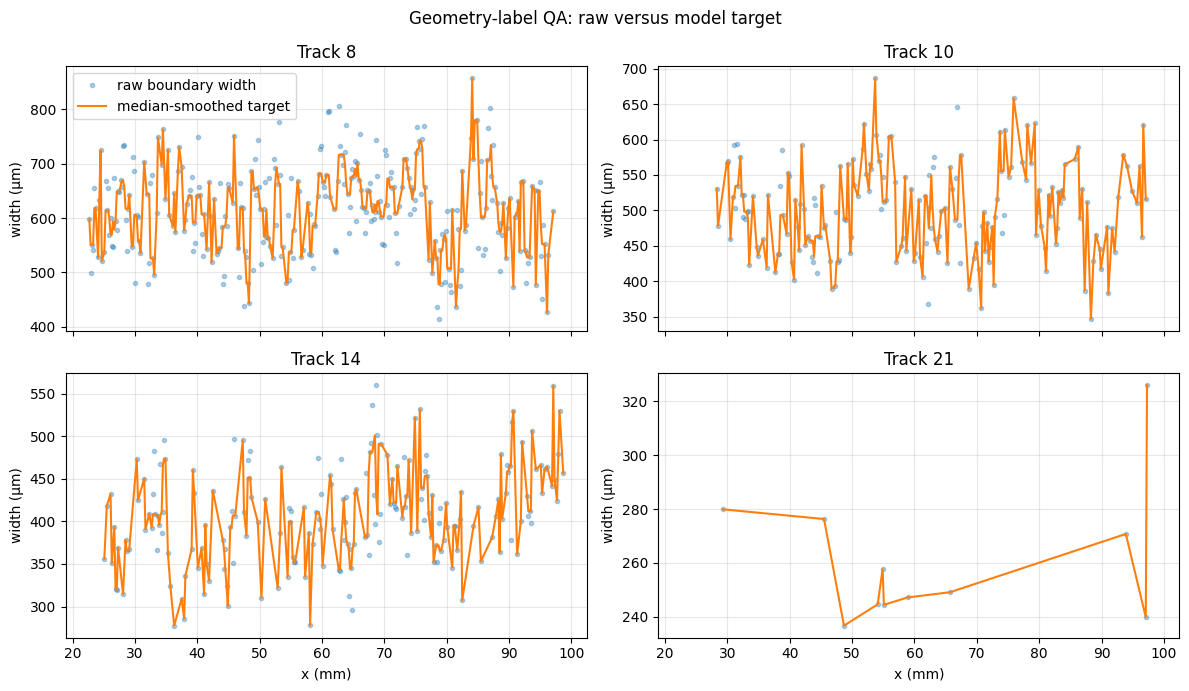

Saved geometry labels to: /content/drive/MyDrive/DSNSFcomp/nsf-fmrg-data-challenge/processed_data/labels_geometry_width.npz


In [8]:
# Build geometry-based labels from actual height values and save them separately from legacy labels.
# Use stable 0.3-mm profiles, a track-calibrated threshold, and final QA.
# model_width_mm is a median-smoothed local descriptor; raw width_mm is preserved.
labels = gen.build_labels(minimum_confidence=0.70, continuity_tolerance_fraction=0.25)
out = PROJECT_DIR / "processed_data" / "labels_geometry_width.npz"
np.savez(out, **labels)
for track_id in TRACK_IDS:
    m = (labels["track_id"] == track_id) & labels["quality"]
    widths = labels["width_mm"][m] * 1000
    model_widths = labels["model_width_mm"][m] * 1000
    print(f"Track {track_id}: accepted={m.sum()}/{(labels['track_id'] == track_id).sum()}",
          f"raw_median_um={np.median(widths) if len(widths) else np.nan:.1f}",
          f"raw_std_um={np.std(widths) if len(widths) else np.nan:.1f}",
          f"model_std_um={np.std(model_widths) if len(model_widths) else np.nan:.1f}")
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, track_id in zip(axes.flat, TRACK_IDS):
    m = (labels["track_id"] == track_id) & labels["quality"]
    ax.plot(labels["x_mm"][m], labels["width_mm"][m] * 1000, ".", alpha=.35, label="raw boundary width")
    ax.plot(labels["x_mm"][m], labels["model_width_mm"][m] * 1000, "-", lw=1.5, label="median-smoothed target")
    ax.set(title=f"Track {track_id}", ylabel="width (µm)"); ax.grid(alpha=.3)
axes[1,0].set_xlabel("x (mm)"); axes[1,1].set_xlabel("x (mm)")
axes[0,0].legend(); fig.suptitle("Geometry-label QA: raw versus model target"); fig.tight_layout(); plt.show()
print("Saved geometry labels to:", out)


In [9]:
## Visualization of width

/content/drive/MyDrive/DSNSFcomp/nsf-fmrg-data-challenge/src/sample_data.py:232: RuntimeWarning: All-NaN slice encountered
  profile_mm = np.nanmedian(z_mm[:, x0:x1], axis=1)


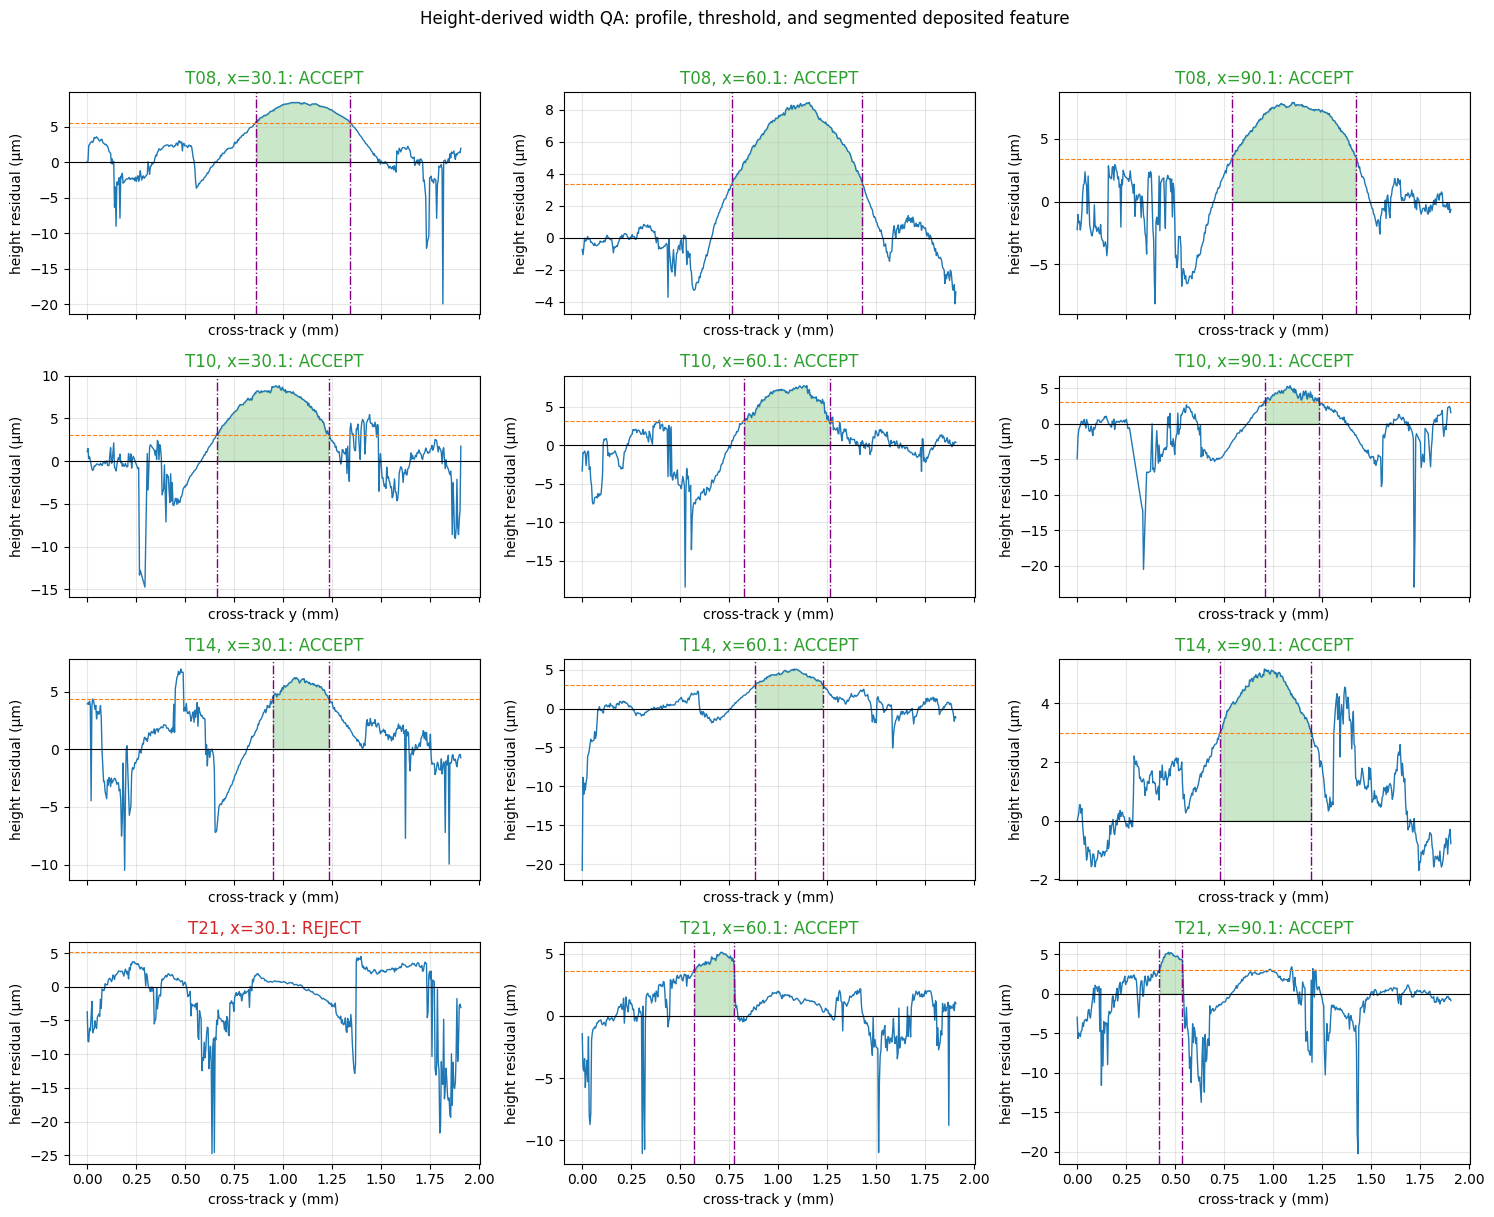

,track_id,x_mm,quality,width_um,left_mm,right_mm,peak_um,threshold_um,confidence,rejection_reason
0,8,30.1,True,481.066695,0.861365,1.342432,8.434466,5.619910,0.750161,accepted
1,8,60.1,True,666.162175,0.764678,1.430841,8.382518,3.385937,0.996806,accepted
2,8,90.1,True,636.190450,0.789186,1.425377,7.793899,3.385937,0.998910,accepted
3,10,30.1,True,569.368331,0.663280,1.232648,8.733388,3.111797,0.940140,accepted
4,10,60.1,True,440.388302,0.826555,1.266943,7.627474,3.163793,0.939339,accepted
5,10,90.1,True,277.828576,0.958011,1.235839,5.081589,3.000000,0.781758,accepted
6,14,30.1,True,286.238045,0.946931,1.233169,6.587314,4.369220,0.753692,accepted
7,14,60.1,True,348.135250,0.882214,1.230349,5.007238,3.000000,0.833900,accepted
8,14,90.1,True,464.945473,0.729832,1.194777,5.108314,3.000000,0.850706,accepted
9,21,30.1,False,NaN,NaN,NaN,3.937193,5.114030,0.000000,feature_too_narrow;feature_touches_y_boundary;...


In [10]:
# Visual QA for actual-height geometry labels. Reject uncertain profiles before ML.
import pandas as pd
qa_x = [30.1, 60.1, 90.1]
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True)
qa_rows = []
for row, track_id in enumerate(TRACK_IDS):
    for col, x_mm in enumerate(qa_x):
        result = gen.width_at(track_id, x_mm)
        ax = axes[row, col]
        ax.plot(result["y_mm"], result["residual_um"], lw=1, color="tab:blue")
        ax.axhline(0, color="black", lw=.8)
        if result["polarity"]:
            ax.axhline(result["polarity"] * result["threshold_um"], color="tab:orange", ls="--", lw=.8)
        ax.fill_between(result["y_mm"], result["residual_um"], 0, where=result["feature_mask"], alpha=.25, color="tab:green")
        ax.set_title(f"T{track_id:02d}, x={x_mm:.1f}: {'ACCEPT' if result['quality'] else 'REJECT'}",
                     color="tab:green" if result["quality"] else "tab:red")
        if np.isfinite(result["left_boundary_mm"]):
            ax.axvline(result["left_boundary_mm"], color="purple", ls="-.", lw=1)
            ax.axvline(result["right_boundary_mm"], color="purple", ls="-.", lw=1)
        ax.set(xlabel="cross-track y (mm)", ylabel="height residual (µm)")
        ax.grid(alpha=.3)
        qa_rows.append({"track_id":track_id, "x_mm":x_mm, "quality":result["quality"],
                        "width_um":result["width_mm"]*1000, "left_mm":result["left_boundary_mm"],
                        "right_mm":result["right_boundary_mm"], "peak_um":result["peak_height_um"],
                        "threshold_um":result["threshold_um"], "confidence":result["confidence"],
                        "rejection_reason":result["rejection_reason"]})
fig.suptitle("Height-derived width QA: profile, threshold, and segmented deposited feature", y=1.01)
fig.tight_layout(); plt.show()
display(pd.DataFrame(qa_rows))


In [11]:
# Load validated geometry labels and leakage-safe SEM samples for all four tracks.
import pandas as pd
# Final exploratory fit: hyperparameters/epoch count were selected earlier using
# the 8/10 -> 14 experiment.  Track 21 remains completely untouched here.
SEM_TRACKS, TRAIN_TRACKS, TEST_TRACK = [8,10,14,21], [8,10,14], 21
FINAL_TRAIN_EPOCHS = 60  # Set from the separate, whole-track validation experiment.
MIN_ACCEPTED_LABELS_BY_TRACK = {8: 100, 10: 100, 14: 50, 21: 11}
label_path = PROJECT_DIR / "processed_data" / "labels_geometry_width.npz"
labels = np.load(label_path, allow_pickle=False)
required_labels = {"track_id","x_mm","width_mm","model_width_mm","quality","left_boundary_mm","right_boundary_mm","confidence"}
missing = required_labels.difference(labels.files)
if missing: raise KeyError(f"Missing geometry-label arrays: {sorted(missing)}")
for track_id in SEM_TRACKS:
    count = int(((labels["track_id"] == track_id) & labels["quality"]).sum())
    if count < MIN_ACCEPTED_LABELS_BY_TRACK[track_id]:
        raise RuntimeError(f"Track {track_id} has only {count} accepted geometry labels (minimum: {MIN_ACCEPTED_LABELS_BY_TRACK[track_id]}). Review the QA plots and calibrate the height-boundary rule before training.")
label_ids = np.array([f"T{int(t):02d}_X{float(x):05.1f}" for t,x in zip(labels["track_id"],labels["x_mm"])])
label_index = {sample_id:i for i,sample_id in enumerate(label_ids)}
sem_by_track = {}
for track_id in SEM_TRACKS:
    path = PROJECT_DIR / "Samples" / "SEM Samples" / f"SEM_samples_Track_{track_id:02d}.npz"
    with np.load(path, allow_pickle=False) as data:
        required = {"sample_ids","track_ids","x_mm","raw_slices","substrate_only_slices","substrate_masks"}
        if required.difference(data.files): raise KeyError(f"Invalid SEM file: {path}")
        reconstructed = np.where(data["substrate_masks"].astype(bool), data["raw_slices"], 0)
        if not np.array_equal(reconstructed.astype(data["substrate_only_slices"].dtype), data["substrate_only_slices"]):
            raise AssertionError(f"Safe SEM reconstruction failed for Track {track_id}")
        sem_by_track[track_id] = {"ids":data["sample_ids"].astype(str), "x":data["x_mm"].astype(float),
                                  "image":data["substrate_only_slices"].copy(), "mask":data["substrate_masks"].astype(bool).copy()}
print("Geometry-label and safe-SEM inputs loaded.")


Geometry-label and safe-SEM inputs loaded.


In [12]:
# Align geometry labels, safe SEM, and track metadata strictly by sample_id.
parts = []
for track_id in SEM_TRACKS:
    eligible = label_ids[(labels["track_id"] == track_id) & labels["quality"]]
    data = sem_by_track[track_id]; ids = np.intersect1d(data["ids"], eligible)
    if not len(ids): raise ValueError(f"No aligned accepted labels for Track {track_id}")
    lookup = {s:i for i,s in enumerate(data["ids"])}
    si = np.array([lookup[s] for s in ids]); li = np.array([label_index[s] for s in ids])
    parts.append((ids, np.full(len(ids),track_id), data["x"][si], data["image"][si], data["mask"][si], labels["model_width_mm"][li]*1000))
aligned_sample_ids = np.concatenate([p[0] for p in parts]); aligned_track_ids = np.concatenate([p[1] for p in parts])
aligned_x_mm = np.concatenate([p[2] for p in parts]); aligned_sem_images = np.concatenate([p[3] for p in parts])
aligned_sem_masks = np.concatenate([p[4] for p in parts]); aligned_width_um = np.concatenate([p[5] for p in parts]).astype(np.float32)
print(pd.DataFrame({"track":aligned_track_ids}).value_counts().sort_index())


track
8        308
10       187
14       196
21        11
Name: count, dtype: int64


In [13]:
# Load the raw five-frame thermal sequence.  Do not collapse time into summary maps.
k = 2
aligned_thermal = np.stack([gen.thermal_tensor(int(t), float(x), k=k) for t,x in zip(aligned_track_ids, aligned_x_mm)])
print("Raw thermal tensors:", aligned_thermal.shape)


Raw thermal tensors: (702, 5, 400, 400)


In [14]:
# Final fit: Tracks 8/10/14.  Track 21 is not used for fitting or model selection.
import tensorflow as tf
from sklearn.metrics import mean_absolute_error
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)
sem_input=np.stack([aligned_sem_images.astype(np.float32)/255, aligned_sem_masks.astype(np.float32)],axis=-1)
y_um=aligned_width_um
train_idx=np.flatnonzero(np.isin(aligned_track_ids,TRAIN_TRACKS)); test_idx=np.flatnonzero(aligned_track_ids==TEST_TRACK)
print("Training tracks:", np.unique(aligned_track_ids[train_idx]))
print("Untouched test track:", np.unique(aligned_track_ids[test_idx]))
thermal_scale=max(float(aligned_thermal[train_idx].max()),1.0)
# (sample, time, height, width, channel): full sequence enters the learned encoder.
thermal_sequence=(aligned_thermal.astype(np.float32) / thermal_scale)[...,None]
y_mean=float(y_um[train_idx].mean()); y_std=float(y_um[train_idx].std()); y_z=(y_um-y_mean)/y_std
x_mean=float(aligned_x_mm[train_idx].mean()); x_std=float(aligned_x_mm[train_idx].std()); x_input=((aligned_x_mm-x_mean)/x_std).astype(np.float32)[:,None]
X_sem_train=sem_input[train_idx]; X_th_train=thermal_sequence[train_idx]; X_x_train=x_input[train_idx]
sem_layer=tf.keras.Input(sem_input.shape[1:],name="sem_input"); a=tf.keras.layers.Conv2D(8,3,activation="relu",padding="same")(sem_layer); a=tf.keras.layers.MaxPool2D(2)(a); a=tf.keras.layers.Conv2D(16,3,activation="relu",padding="same")(a); a=tf.keras.layers.GlobalAveragePooling2D()(a)
# Shared spatial CNN per frame, then a GRU over the ordered five-frame sequence.
th_layer=tf.keras.Input(thermal_sequence.shape[1:],name="thermal_sequence")
b=tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(8,5,strides=4,activation="relu",padding="same"))(th_layer)
b=tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(16,3,strides=2,activation="relu",padding="same"))(b)
b=tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(24,3,strides=2,activation="relu",padding="same"))(b)
b=tf.keras.layers.TimeDistributed(tf.keras.layers.GlobalAveragePooling2D())(b)
b=tf.keras.layers.GRU(32,dropout=.10)(b)
x_layer=tf.keras.Input((1,),name="x_input"); c=tf.keras.layers.Dense(8,activation="relu")(x_layer)
z=tf.keras.layers.Concatenate()([a,b,c]); z=tf.keras.layers.Dense(32,activation="relu")(z); z=tf.keras.layers.Dropout(.2)(z); out=tf.keras.layers.Dense(1)(z)
model=tf.keras.Model([sem_layer,th_layer,x_layer],out); model.compile(tf.keras.optimizers.Adam(5e-4),loss=tf.keras.losses.Huber(delta=1.0),metrics=["mae"])
checkpoint=PROJECT_DIR/"processed_data"/"final_t8_t10_t14_sequence.keras"
history=model.fit({"sem_input":X_sem_train,"thermal_sequence":X_th_train,"x_input":X_x_train},y_z[train_idx],epochs=FINAL_TRAIN_EPOCHS,batch_size=8,verbose=2)
model.save(checkpoint)
print(f"Saved final model after {FINAL_TRAIN_EPOCHS} fixed epochs: {checkpoint}")


Training tracks: [ 8 10 14]
Untouched test track: [21]
Epoch 1/60
87/87 - 8s - 97ms/step - loss: 0.4512 - mae: 0.8500
Epoch 2/60
87/87 - 2s - 21ms/step - loss: 0.4496 - mae: 0.8462
Epoch 3/60
87/87 - 2s - 20ms/step - loss: 0.4447 - mae: 0.8388
Epoch 4/60
87/87 - 2s - 20ms/step - loss: 0.4431 - mae: 0.8372
Epoch 5/60
87/87 - 2s - 21ms/step - loss: 0.4394 - mae: 0.8332
Epoch 6/60
87/87 - 2s - 21ms/step - loss: 0.4345 - mae: 0.8275
Epoch 7/60
87/87 - 2s - 20ms/step - loss: 0.4259 - mae: 0.8174
Epoch 8/60
87/87 - 2s - 21ms/step - loss: 0.4157 - mae: 0.8077
Epoch 9/60
87/87 - 2s - 21ms/step - loss: 0.4057 - mae: 0.7921
Epoch 10/60
87/87 - 2s - 21ms/step - loss: 0.3947 - mae: 0.7824
Epoch 11/60
87/87 - 2s - 21ms/step - loss: 0.3862 - mae: 0.7672
Epoch 12/60
87/87 - 2s - 21ms/step - loss: 0.3716 - mae: 0.7503
Epoch 13/60
87/87 - 2s - 21ms/step - loss: 0.3675 - mae: 0.7469
Epoch 14/60
87/87 - 2s - 21ms/step - loss: 0.3537 - mae: 0.7289
Epoch 15/60
87/87 - 2s - 21ms/step - loss: 0.3492 - mae: 0

In [15]:
print("Thermal sequence used by the model:", thermal_sequence.shape)
print("Train-only normalization scale:", thermal_scale)
print("Sequence mean/std:", float(thermal_sequence.mean()), float(thermal_sequence.std()))


Thermal sequence used by the model: (702, 5, 400, 400, 1)
Train-only normalization scale: 2989.0
Sequence mean/std: 0.3919272720813751 0.05246146395802498


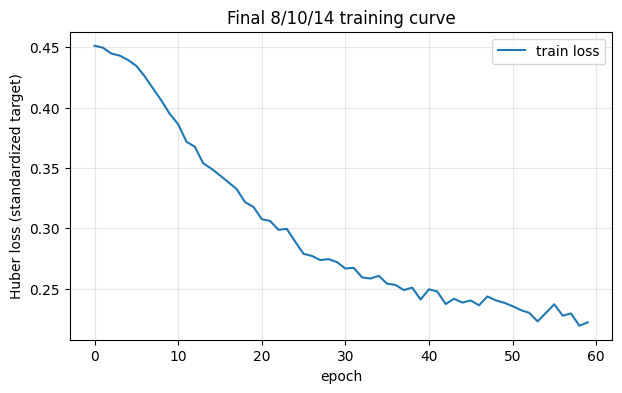

In [16]:
# No validation is used in the final fit: Track 21 remains untouched until final evaluation.
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.xlabel("epoch"); plt.ylabel("Huber loss (standardized target)"); plt.title("Final 8/10/14 training curve")
plt.grid(alpha=.3); plt.legend(); plt.show()


## Width labels over the whole grid

`build_labels()` sweeps every frame-centre x for all tracks and returns `width_mm` + a `quality`
flag (False where x is outside a track's height coverage or an edge is clipped).

In [17]:
# The next cell is the single final evaluation on Track 21.
# Do not use its MAE, predictions, or error table to alter this model.


In [18]:
# Single final evaluation on the untouched Track 21.
if len(test_idx) < 20: print(f"WARNING: only {len(test_idx)} Track-21 labels; treat this as exploratory, not a final benchmark.")
pred_test=model.predict({"sem_input":sem_input[test_idx],"thermal_sequence":thermal_sequence[test_idx],"x_input":x_input[test_idx]})[:,0]*y_std+y_mean
true_test=y_um[test_idx]; baseline_test=np.full_like(true_test,y_mean)
print("Track-21 MAE model / baseline:",mean_absolute_error(true_test,pred_test),mean_absolute_error(true_test,baseline_test))
result=pd.DataFrame({"sample_id":aligned_sample_ids[test_idx],"x_mm":aligned_x_mm[test_idx],"true_width_um":true_test,"predicted_width_um":pred_test,"error_um":pred_test-true_test}); result["abs_error_um"]=result.error_um.abs(); display(result.sort_values("abs_error_um",ascending=False).head(10))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
Track-21 MAE model / baseline: 47.76984786987305 263.9023132324219


,sample_id,x_mm,true_width_um,predicted_width_um,error_um,abs_error_um
9,T21_X097.1,97.1,239.851089,373.599854,133.748764,133.748764
10,T21_X097.3,97.3,326.056549,448.026276,121.969727,121.969727
8,T21_X093.9,93.9,270.774689,387.424896,116.650208,116.650208
7,T21_X065.7,65.7,249.123505,310.258453,61.134949,61.134949
2,T21_X048.7,48.7,236.693207,262.795380,26.102173,26.102173
5,T21_X055.1,55.1,244.438339,268.782196,24.343857,24.343857
3,T21_X054.1,54.1,244.621246,263.845337,19.224091,19.224091
0,T21_X029.3,29.3,279.919800,265.493683,-14.426117,14.426117
6,T21_X058.9,58.9,247.182983,250.137543,2.954559,2.954559
1,T21_X045.5,45.5,276.330353,273.582947,-2.747406,2.747406


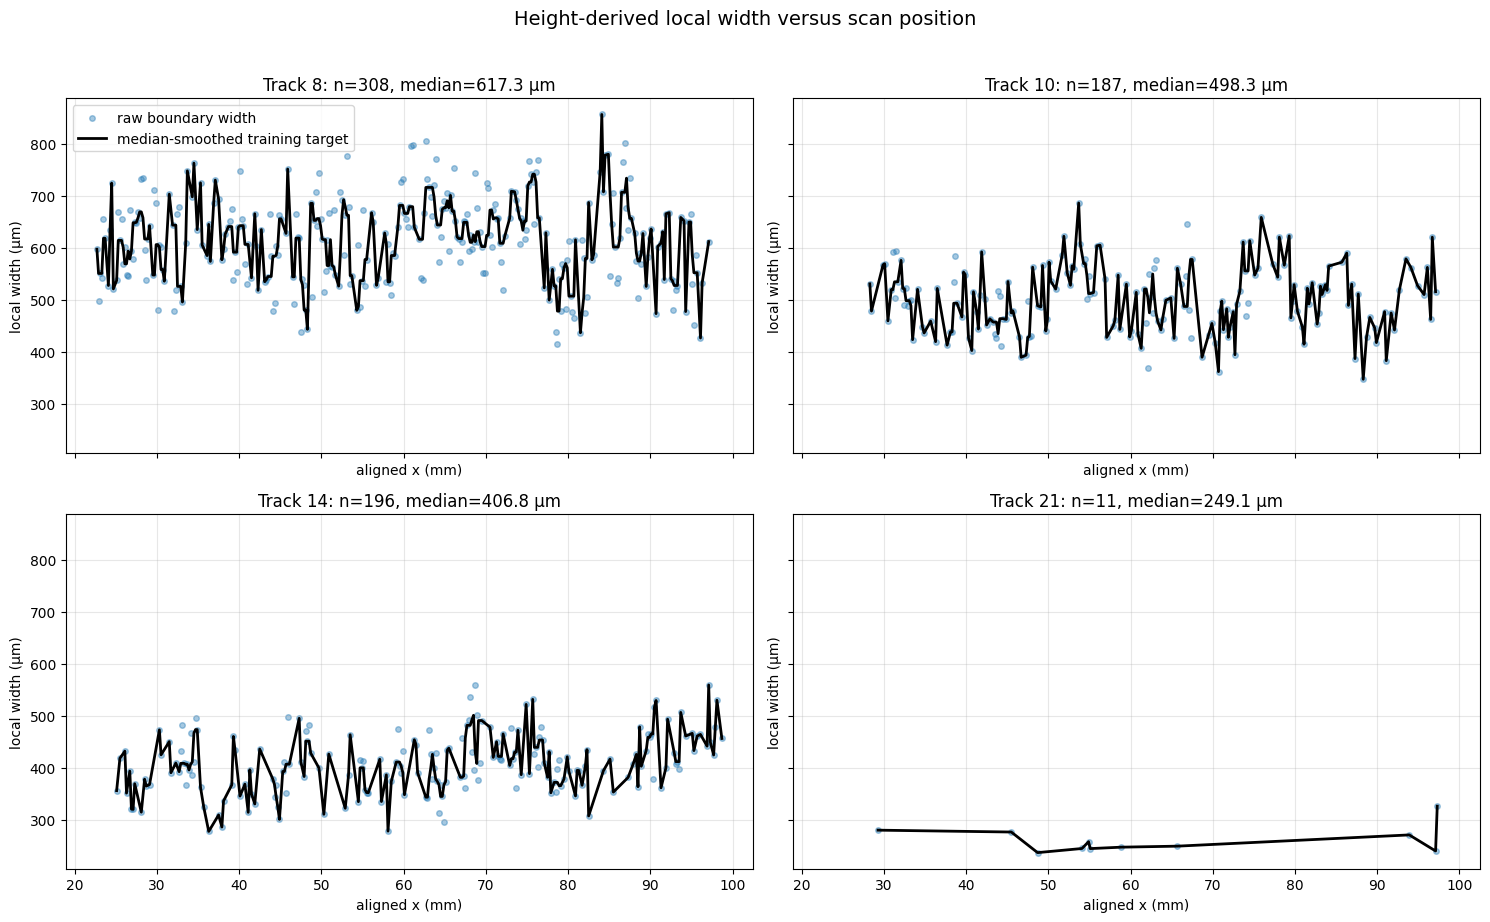

In [19]:
# Local geometry width versus position for every track.


fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=True)

for ax, track_id in zip(axes.flat, SEM_TRACKS):
    accepted = (
        (labels["track_id"] == track_id)
        & labels["quality"]
        & np.isfinite(labels["width_mm"])
    )

    x = labels["x_mm"][accepted]
    raw_width_um = labels["width_mm"][accepted] * 1000
    model_width_um = labels["model_width_mm"][accepted] * 1000

    order = np.argsort(x)
    x = x[order]
    raw_width_um = raw_width_um[order]
    model_width_um = model_width_um[order]

    ax.scatter(
        x, raw_width_um,
        s=16, alpha=0.40, color="tab:blue",
        label="raw boundary width",
    )
    ax.plot(
        x, model_width_um,
        lw=2, color="black",
        label="median-smoothed training target",
    )

    ax.set_title(
        f"Track {track_id}: n={len(x)}, "
        f"median={np.median(model_width_um):.1f} µm"
    )
    ax.set_xlabel("aligned x (mm)")
    ax.set_ylabel("local width (µm)")
    ax.grid(alpha=0.3)

axes[0, 0].legend(loc="best")
fig.suptitle("Height-derived local width versus scan position", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

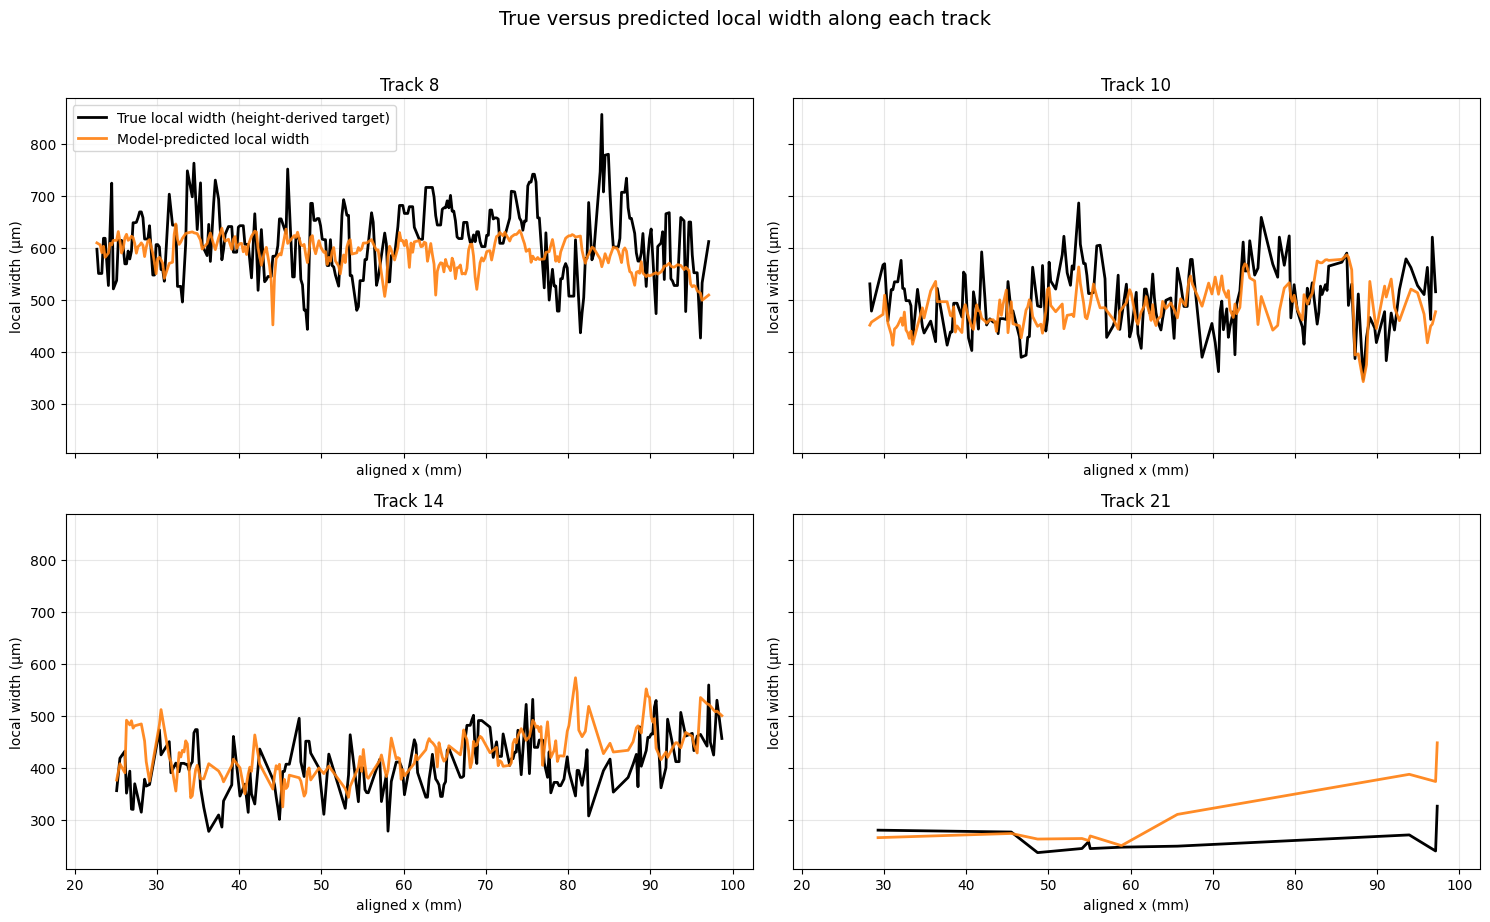

In [20]:
# True local width versus model-predicted local width for all tracks.
pred_all_um = model.predict(
    {
        "sem_input": sem_input,
        "thermal_sequence": thermal_sequence,
        "x_input": x_input,
    },
    verbose=0,
)[:, 0] * y_std + y_mean

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=True)

for ax, track_id in zip(axes.flat, SEM_TRACKS):
    mask = aligned_track_ids == track_id
    order = np.argsort(aligned_x_mm[mask])

    x = aligned_x_mm[mask][order]

    # True target: height-derived, median-smoothed local width.
    true_width_um = aligned_width_um[mask][order]

    # Predicted width: output of the trained CNN + GRU model.
    predicted_width_um = pred_all_um[mask][order]

    ax.plot(
        x, true_width_um,
        color="black", lw=2, label="True local width (height-derived target)",
    )
    ax.plot(
        x, predicted_width_um,
        color="tab:orange", lw=2, alpha=0.9,
        label="Model-predicted local width",
    )

    ax.set_title(f"Track {track_id}")
    ax.set_xlabel("aligned x (mm)")
    ax.set_ylabel("local width (µm)")
    ax.grid(alpha=0.3)

axes[0, 0].legend(loc="best")
fig.suptitle("True versus predicted local width along each track", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

In [21]:
aligned_label_idx = np.array([label_index[s] for s in aligned_sample_ids])
descriptor_frame = pd.DataFrame({
    'sample_id': aligned_sample_ids, 'track_id': aligned_track_ids, 'x_mm': aligned_x_mm,
    'width_um': aligned_width_um,
    'left_boundary_um': labels['left_boundary_mm'][aligned_label_idx] * 1000,
    'right_boundary_um': labels['right_boundary_mm'][aligned_label_idx] * 1000,
})
display(descriptor_frame.head())
print('Boundary targets are true height-derived crossings, not model predictions.')

,sample_id,track_id,x_mm,width_um,left_boundary_um,right_boundary_um
0,T08_X022.7,8,22.7,597.259644,765.665583,1362.925247
1,T08_X022.9,8,22.9,550.638306,829.843279,1328.115573
2,T08_X023.1,8,23.1,550.638306,800.429829,1351.068164
3,T08_X023.3,8,23.3,550.638306,808.351896,1349.798122
4,T08_X023.5,8,23.5,618.349915,752.831364,1407.868508


Boundary targets are true height-derived crossings, not model predictions.


In [22]:
# 2 — Contour deviation target: RMS departure (µm) from a smooth deposited-feature contour.
from scipy.ndimage import gaussian_filter1d
contour_deviation_um = np.full(len(descriptor_frame), np.nan, dtype=np.float32)
for i, (track_id, x_mm) in enumerate(zip(descriptor_frame.track_id, descriptor_frame.x_mm)):
    profile = gen.width_at(int(track_id), float(x_mm))
    signal = profile['smoothed_residual_um'][profile['feature_mask']]
    if signal.size >= 8 and np.isfinite(signal).all():
        contour_deviation_um[i] = np.sqrt(np.mean((signal - gaussian_filter1d(signal, 4.0)) ** 2))
descriptor_frame['contour_deviation_um'] = contour_deviation_um
print(descriptor_frame.groupby('track_id')['contour_deviation_um'].agg(['count','median','mean','std']).round(3))

/content/drive/MyDrive/DSNSFcomp/nsf-fmrg-data-challenge/src/sample_data.py:232: RuntimeWarning: All-NaN slice encountered
  profile_mm = np.nanmedian(z_mm[:, x0:x1], axis=1)


          count  median   mean    std
track_id                             
8           308   0.059  0.060  0.011
10          187   0.086  0.089  0.023
14          196   0.068  0.071  0.016
21           11   0.081  0.099  0.044


In [23]:
# 3 — Edge roughness target: local high-frequency RMS motion of both boundaries (µm).
descriptor_frame['edge_roughness_um'] = np.nan
for track_id, group in descriptor_frame.groupby('track_id', sort=False):
    idx = group.sort_values('x_mm').index.to_numpy()
    left = descriptor_frame.loc[idx, 'left_boundary_um'].to_numpy(); right = descriptor_frame.loc[idx, 'right_boundary_um'].to_numpy()
    left_resid = left - gaussian_filter1d(left, 5.0); right_resid = right - gaussian_filter1d(right, 5.0)
    descriptor_frame.loc[idx, 'edge_roughness_um'] = np.sqrt((left_resid**2 + right_resid**2) / 2.0)
print(descriptor_frame.groupby('track_id')['edge_roughness_um'].agg(['median','mean','std']).round(3))

          median    mean     std
track_id                        
8         36.494  38.461  18.537
10        33.283  34.055  17.988
14        30.987  31.800  15.451
21        65.995  70.473  58.638


In [24]:
# 4 — Waviness target: local low-frequency centreline displacement (µm).
descriptor_frame['waviness_um'] = np.nan
for track_id, group in descriptor_frame.groupby('track_id', sort=False):
    idx = group.sort_values('x_mm').index.to_numpy()
    centre_um = (descriptor_frame.loc[idx, 'left_boundary_um'].to_numpy() + descriptor_frame.loc[idx, 'right_boundary_um'].to_numpy()) / 2.0
    local_centre = gaussian_filter1d(centre_um, 3.0); long_centre = gaussian_filter1d(centre_um, 15.0)
    descriptor_frame.loc[idx, 'waviness_um'] = np.abs(local_centre - long_centre)
print(descriptor_frame.groupby('track_id')['waviness_um'].agg(['median','mean','std']).round(3))

          median    mean     std
track_id                        
8          9.518  11.941   9.400
10         8.070   9.657   7.003
14         7.944   8.856   6.351
21        40.993  35.587  17.617


In [25]:
# 5 — Explicit vector of geometry descriptors for multi-output learning.
DESCRIPTOR_NAMES = ['width_um', 'left_boundary_um', 'right_boundary_um', 'contour_deviation_um', 'edge_roughness_um', 'waviness_um']
descriptor_quality = np.isfinite(descriptor_frame[DESCRIPTOR_NAMES].to_numpy()).all(axis=1)
geometry_target_um = descriptor_frame.loc[descriptor_quality, DESCRIPTOR_NAMES].to_numpy(np.float32)
geometry_target_indices = np.flatnonzero(descriptor_quality)
print('Descriptor vector order:', DESCRIPTOR_NAMES)
print('Usable multi-descriptor samples:', len(geometry_target_um), '/', len(descriptor_frame))

Descriptor vector order: ['width_um', 'left_boundary_um', 'right_boundary_um', 'contour_deviation_um', 'edge_roughness_um', 'waviness_um']
Usable multi-descriptor samples: 702 / 702


In [41]:
# 6 — Fresh-model builder. Each fold computes thermal/x/target normalization from its own training tracks only.
import tensorflow as tf
descriptor_track_ids = aligned_track_ids[geometry_target_indices]
descriptor_x_mm = aligned_x_mm[geometry_target_indices].astype(np.float32)
descriptor_sem = sem_input[geometry_target_indices]
descriptor_raw_thermal = aligned_thermal[geometry_target_indices].astype(np.float32)[..., None]
descriptor_meta = descriptor_frame.loc[descriptor_quality, ['sample_id','track_id','x_mm']].reset_index(drop=True)
def gaussian_nll(y_true, y_pred):
    d = tf.shape(y_true)[1]; mean, log_var = y_pred[:, :d], tf.clip_by_value(y_pred[:, d:], -8., 5.)
    return tf.reduce_mean(0.5 * (tf.exp(-log_var) * tf.square(y_true - mean) + log_var))
def build_descriptor_model():
    sem_in = tf.keras.Input(descriptor_sem.shape[1:], name='sem_input'); a = tf.keras.layers.Conv2D(8,3,activation='relu',padding='same')(sem_in); a = tf.keras.layers.MaxPool2D(2)(a); a = tf.keras.layers.Conv2D(16,3,activation='relu',padding='same')(a); a = tf.keras.layers.GlobalAveragePooling2D()(a)
    th_in = tf.keras.Input(descriptor_raw_thermal.shape[1:], name='thermal_sequence'); b = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(8,5,strides=4,activation='relu',padding='same'))(th_in); b = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(16,3,strides=2,activation='relu',padding='same'))(b); b = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(24,3,strides=2,activation='relu',padding='same'))(b); b = tf.keras.layers.TimeDistributed(tf.keras.layers.GlobalAveragePooling2D())(b); b = tf.keras.layers.GRU(32,dropout=.1)(b)
    x_in = tf.keras.Input((1,), name='x_input'); c = tf.keras.layers.Dense(8,activation='relu')(x_in)
    h = tf.keras.layers.Dense(48,activation='relu')(tf.keras.layers.Concatenate()([a,b,c])); h = tf.keras.layers.Dropout(.2)(h)
    model = tf.keras.Model([sem_in,th_in,x_in], tf.keras.layers.Dense(2 * len(DESCRIPTOR_NAMES))(h))
    model.compile(tf.keras.optimizers.Adam(5e-4), loss=gaussian_nll); return model
def fit_predict_descriptor_fold(train_tracks, heldout_track, model_path=None):
    train = np.isin(descriptor_track_ids, train_tracks); heldout = descriptor_track_ids == heldout_track
    if not train.any() or not heldout.any(): raise ValueError('Empty train or held-out descriptor fold')
    thermal_scale = max(float(descriptor_raw_thermal[train].max()), 1.0); sequence = descriptor_raw_thermal / thermal_scale
    y_mean = geometry_target_um[train].mean(0); y_std = geometry_target_um[train].std(0).clip(1e-6); y_z = (geometry_target_um-y_mean)/y_std
    x_mean = float(descriptor_x_mm[train].mean()); x_std = max(float(descriptor_x_mm[train].std()), 1e-6); x_z = ((descriptor_x_mm-x_mean)/x_std)[:,None]
    tf.keras.backend.clear_session(); tf.keras.utils.set_random_seed(42); fold_model = build_descriptor_model()
    fold_model.fit({'sem_input':descriptor_sem[train], 'thermal_sequence':sequence[train], 'x_input':x_z[train]}, y_z[train], epochs=FINAL_TRAIN_EPOCHS, batch_size=8, verbose=2)
    if model_path is not None: fold_model.save(model_path)
    output = fold_model.predict({'sem_input':descriptor_sem[heldout], 'thermal_sequence':sequence[heldout], 'x_input':x_z[heldout]}, verbose=0); d=len(DESCRIPTOR_NAMES)
    table = descriptor_meta.loc[heldout].reset_index(drop=True).copy()
    for j,name in enumerate(DESCRIPTOR_NAMES): table[f'true_{name}']=geometry_target_um[heldout,j]; table[f'predicted_{name}']=output[:,j]*y_std[j]+y_mean[j]; table[f'aleatoric_std_{name}']=np.exp(np.clip(output[:,d+j],-8.,5.)/2)*y_std[j]; table[f'abs_residual_{name}']=np.abs(table[f'true_{name}']-table[f'predicted_{name}'])
    table['fold_train_tracks'] = str(list(train_tracks)); table['fold_heldout_track'] = heldout_track
    return table


In [42]:
# 7 — Three leave-one-track-out runs. Each held-out track is unseen by its fold model.
LOTO_FOLDS = [([8,10],14), ([8,14],10), ([10,14],8)]
oof_tables = []
for fold_train_tracks, fold_heldout_track in LOTO_FOLDS:
    print(f'LOTO fold: train {fold_train_tracks} -> predict Track {fold_heldout_track}')
    oof_tables.append(fit_predict_descriptor_fold(fold_train_tracks, fold_heldout_track))
oof_descriptor_predictions = pd.concat(oof_tables, ignore_index=True)
oof_path = PROJECT_DIR / 'processed_data' / 'oof_descriptor_predictions.csv'
oof_descriptor_predictions.to_csv(oof_path, index=False)
conformal_radii_um = {}
for name in DESCRIPTOR_NAMES:
    residual = oof_descriptor_predictions[f'abs_residual_{name}'].dropna().to_numpy()
    level = min(1.0, np.ceil((residual.size + 1) * .95) / residual.size)
    conformal_radii_um[name] = float(np.quantile(residual, level, method='higher'))
print('Saved out-of-track descriptor residuals to:', oof_path)
print('Pooled 95% conformal radii (µm):', conformal_radii_um)
display(oof_descriptor_predictions.head())

LOTO fold: train [8, 10] -> predict Track 14
Epoch 1/60
62/62 - 5s - 85ms/step - loss: 0.5073
Epoch 2/60
62/62 - 1s - 21ms/step - loss: 0.4942
Epoch 3/60
62/62 - 1s - 21ms/step - loss: 0.4891
Epoch 4/60
62/62 - 1s - 21ms/step - loss: 0.4830
Epoch 5/60
62/62 - 1s - 21ms/step - loss: 0.4778
Epoch 6/60
62/62 - 1s - 21ms/step - loss: 0.4748
Epoch 7/60
62/62 - 1s - 21ms/step - loss: 0.4736
Epoch 8/60
62/62 - 1s - 21ms/step - loss: 0.4672
Epoch 9/60
62/62 - 1s - 21ms/step - loss: 0.4632
Epoch 10/60
62/62 - 1s - 21ms/step - loss: 0.4585
Epoch 11/60
62/62 - 1s - 21ms/step - loss: 0.4532
Epoch 12/60
62/62 - 1s - 22ms/step - loss: 0.4505
Epoch 13/60
62/62 - 1s - 21ms/step - loss: 0.4476
Epoch 14/60
62/62 - 1s - 21ms/step - loss: 0.4429
Epoch 15/60
62/62 - 1s - 21ms/step - loss: 0.4402
Epoch 16/60
62/62 - 1s - 21ms/step - loss: 0.4356
Epoch 17/60
62/62 - 1s - 21ms/step - loss: 0.4284
Epoch 18/60
62/62 - 1s - 21ms/step - loss: 0.4252
Epoch 19/60
62/62 - 1s - 21ms/step - loss: 0.4204
Epoch 20/60
62

LOTO fold: train [10, 14] -> predict Track 8
Epoch 1/60
48/48 - 5s - 101ms/step - loss: 0.5027
Epoch 2/60
48/48 - 1s - 21ms/step - loss: 0.4932
Epoch 3/60
48/48 - 1s - 21ms/step - loss: 0.4876
Epoch 4/60
48/48 - 1s - 21ms/step - loss: 0.4837
Epoch 5/60
48/48 - 1s - 20ms/step - loss: 0.4795
Epoch 6/60
48/48 - 1s - 21ms/step - loss: 0.4772
Epoch 7/60
48/48 - 1s - 21ms/step - loss: 0.4755
Epoch 8/60
48/48 - 1s - 21ms/step - loss: 0.4742
Epoch 9/60
48/48 - 1s - 21ms/step - loss: 0.4678
Epoch 10/60
48/48 - 1s - 21ms/step - loss: 0.4726
Epoch 11/60
48/48 - 1s - 20ms/step - loss: 0.4737
Epoch 12/60
48/48 - 1s - 20ms/step - loss: 0.4659
Epoch 13/60
48/48 - 1s - 20ms/step - loss: 0.4708
Epoch 14/60
48/48 - 1s - 20ms/step - loss: 0.4691
Epoch 15/60
48/48 - 1s - 21ms/step - loss: 0.4669
Epoch 16/60
48/48 - 1s - 21ms/step - loss: 0.4654
Epoch 17/60
48/48 - 1s - 20ms/step - loss: 0.4688
Epoch 18/60
48/48 - 1s - 20ms/step - loss: 0.4615
Epoch 19/60
48/48 - 1s - 21ms/step - loss: 0.4612
Epoch 20/60
4

Saved out-of-track descriptor residuals to: /content/drive/MyDrive/DSNSFcomp/nsf-fmrg-data-challenge/processed_data/oof_descriptor_predictions.csv
Pooled 95% conformal radii (µm): {'width_um': 215.9766845703125, 'left_boundary_um': 172.81134033203125, 'right_boundary_um': 233.5584716796875, 'contour_deviation_um': 0.0480523444712162, 'edge_roughness_um': 34.02361297607422, 'waviness_um': 17.216615676879883}


,sample_id,track_id,x_mm,true_width_um,predicted_width_um,aleatoric_std_width_um,abs_residual_width_um,true_left_boundary_um,predicted_left_boundary_um,aleatoric_std_left_boundary_um,...,true_edge_roughness_um,predicted_edge_roughness_um,aleatoric_std_edge_roughness_um,abs_residual_edge_roughness_um,true_waviness_um,predicted_waviness_um,aleatoric_std_waviness_um,abs_residual_waviness_um,fold_train_tracks,fold_heldout_track
0,T14_X025.1,14,25.1,355.959900,485.908203,52.298397,129.948303,892.896118,696.507507,51.166542,...,13.228185,33.961868,15.936948,20.733685,6.994196,12.028871,6.429133,5.034674,"[8, 10]",14
1,T14_X025.5,14,25.5,418.342102,494.917877,53.471344,76.575775,859.004578,702.430847,51.701870,...,24.608711,34.299309,16.074776,9.690598,7.689583,12.199186,6.627580,4.509604,"[8, 10]",14
2,T14_X026.1,14,26.1,431.933563,493.802185,53.479328,61.868622,884.009155,702.659973,51.725880,...,35.112350,34.292904,16.098379,0.819447,8.943106,12.124600,6.594155,3.181495,"[8, 10]",14
3,T14_X026.3,14,26.3,351.176361,518.011780,58.310902,166.835419,895.549438,727.087646,55.108154,...,14.199408,35.219326,16.497490,21.019918,10.491291,11.651127,6.956707,1.159836,"[8, 10]",14
4,T14_X026.7,14,26.7,393.511719,532.737976,59.810093,139.226257,873.735657,738.232788,55.827732,...,13.596522,35.832474,16.837502,22.235950,11.961205,11.962721,7.231266,0.001516,"[8, 10]",14


In [43]:
# 8 — Final model: train all 8/10/14, predict untouched Track 21, then apply fixed pooled radii.
final_test_predictions = fit_predict_descriptor_fold([8,10,14], 21, PROJECT_DIR / 'processed_data' / 'final_t8_t10_t14_descriptors.keras')
calibrated_test_predictions = final_test_predictions.copy()
coverage = {}
for name in DESCRIPTOR_NAMES:
    radius = conformal_radii_um[name]
    calibrated_test_predictions[f'calibrated_radius_{name}'] = radius
    calibrated_test_predictions[f'lower_{name}'] = calibrated_test_predictions[f'predicted_{name}'] - radius
    calibrated_test_predictions[f'upper_{name}'] = calibrated_test_predictions[f'predicted_{name}'] + radius
    inside = (calibrated_test_predictions[f'true_{name}'] >= calibrated_test_predictions[f'lower_{name}']) & (calibrated_test_predictions[f'true_{name}'] <= calibrated_test_predictions[f'upper_{name}'])
    coverage[name] = float(inside.mean()) if len(inside) else np.nan
final_path = PROJECT_DIR / 'processed_data' / 'track21_calibrated_descriptor_predictions.csv'
calibrated_test_predictions.to_csv(final_path, index=False)
print('Exploratory Track-21 nominal-95% interval coverage:', coverage)
print('Saved calibrated Track-21 predictions to:', final_path)
display(calibrated_test_predictions.head())

Epoch 1/60
87/87 - 6s - 64ms/step - loss: 0.5050
Epoch 2/60
87/87 - 2s - 21ms/step - loss: 0.4998
Epoch 3/60
87/87 - 2s - 21ms/step - loss: 0.4982
Epoch 4/60
87/87 - 2s - 22ms/step - loss: 0.4970
Epoch 5/60
87/87 - 2s - 20ms/step - loss: 0.4958
Epoch 6/60
87/87 - 2s - 20ms/step - loss: 0.4922
Epoch 7/60
87/87 - 2s - 20ms/step - loss: 0.4905
Epoch 8/60
87/87 - 2s - 20ms/step - loss: 0.4864
Epoch 9/60
87/87 - 2s - 20ms/step - loss: 0.4830
Epoch 10/60
87/87 - 2s - 20ms/step - loss: 0.4810
Epoch 11/60
87/87 - 2s - 20ms/step - loss: 0.4763
Epoch 12/60
87/87 - 2s - 20ms/step - loss: 0.4693
Epoch 13/60
87/87 - 2s - 20ms/step - loss: 0.4613
Epoch 14/60
87/87 - 2s - 20ms/step - loss: 0.4551
Epoch 15/60
87/87 - 2s - 20ms/step - loss: 0.4482
Epoch 16/60
87/87 - 2s - 20ms/step - loss: 0.4368
Epoch 17/60
87/87 - 2s - 20ms/step - loss: 0.4342
Epoch 18/60
87/87 - 2s - 20ms/step - loss: 0.4249
Epoch 19/60
87/87 - 2s - 21ms/step - loss: 0.4244
Epoch 20/60
87/87 - 2s - 20ms/step - loss: 0.4114
Epoch 21/

,sample_id,track_id,x_mm,true_width_um,predicted_width_um,aleatoric_std_width_um,abs_residual_width_um,true_left_boundary_um,predicted_left_boundary_um,aleatoric_std_left_boundary_um,...,upper_right_boundary_um,calibrated_radius_contour_deviation_um,lower_contour_deviation_um,upper_contour_deviation_um,calibrated_radius_edge_roughness_um,lower_edge_roughness_um,upper_edge_roughness_um,calibrated_radius_waviness_um,lower_waviness_um,upper_waviness_um
0,T21_X029.3,21,29.3,279.919800,301.373535,57.742584,21.453735,949.307556,787.274719,91.664032,...,1332.663452,0.048052,0.039791,0.135896,34.023613,-5.467321,62.579903,17.216616,-12.145481,22.287750
1,T21_X045.5,21,45.5,276.330353,312.911987,55.401379,36.581635,934.245483,794.634521,73.280502,...,1348.852051,0.048052,0.039159,0.135264,34.023613,-6.293121,61.754105,17.216616,-11.186884,23.246347
2,T21_X048.7,21,48.7,236.693207,332.952820,59.252102,96.259613,973.401672,789.536011,78.305466,...,1363.808228,0.048052,0.039091,0.135195,34.023613,-3.343550,64.703674,17.216616,-11.086182,23.347050
3,T21_X054.1,21,54.1,244.621246,326.058899,57.685329,81.437653,1171.200195,793.093201,68.665810,...,1363.557007,0.048052,0.038974,0.135079,34.023613,-4.503639,63.543587,17.216616,-11.069502,23.363729
4,T21_X054.9,21,54.9,257.705719,345.821045,60.207314,88.115326,871.551025,790.167664,72.910545,...,1378.701050,0.048052,0.038131,0.134236,34.023613,-2.912432,65.134796,17.216616,-10.788557,23.644674


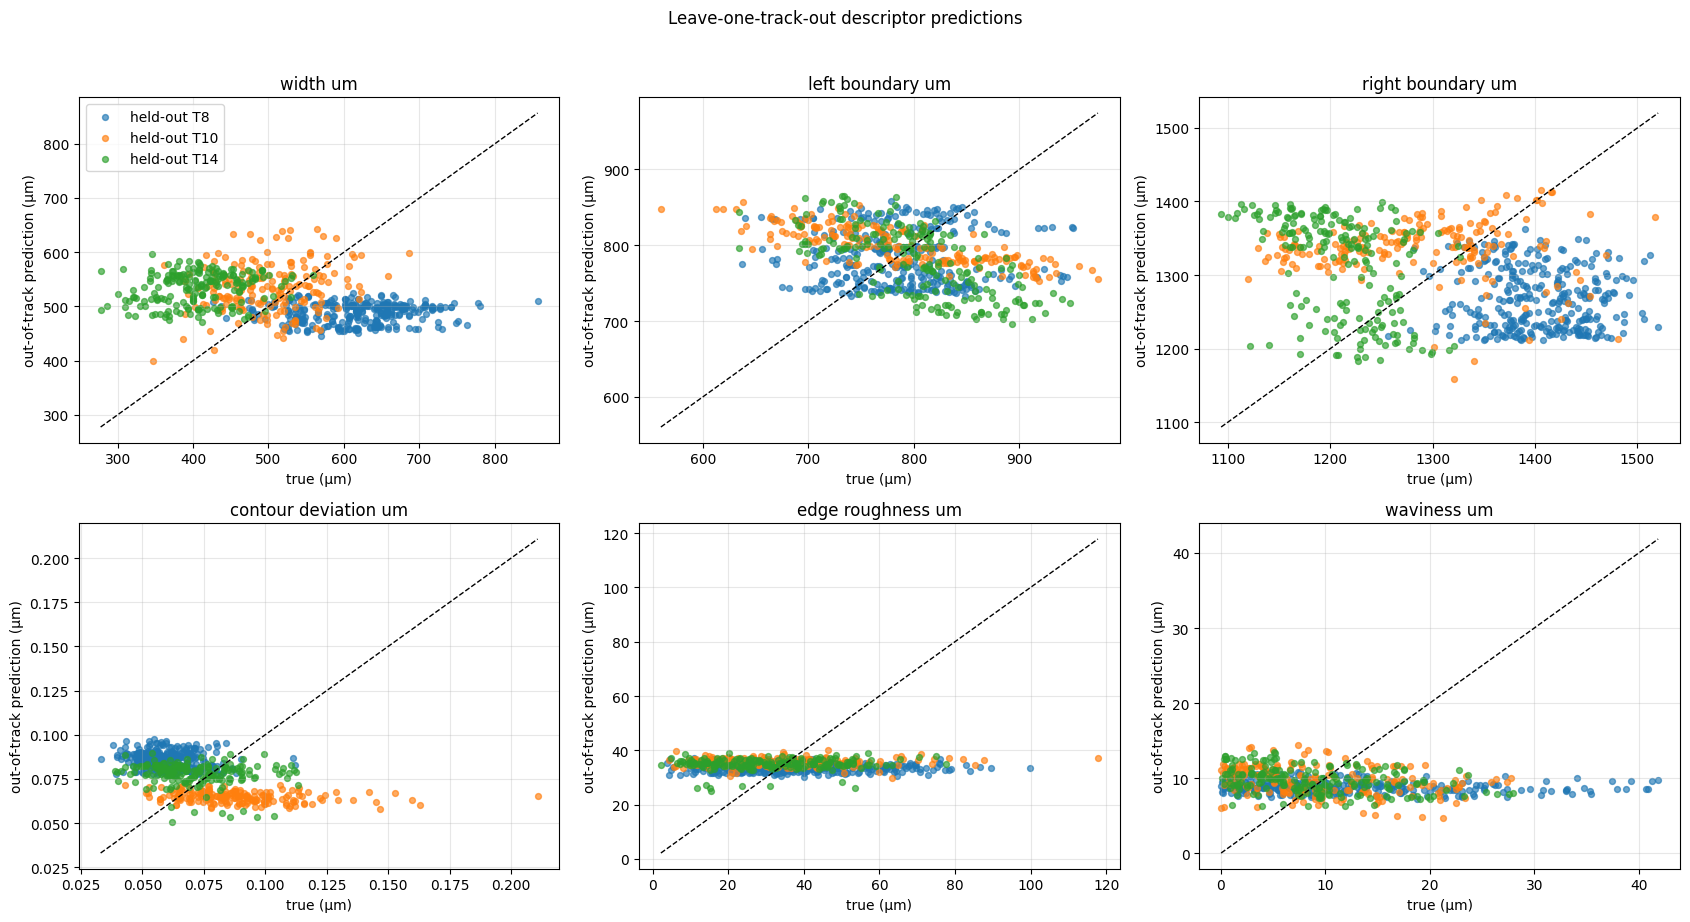

In [47]:
# 9 — Leave-one-track-out calibration diagnostics: true versus predicted descriptors.
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
colors = {8:'tab:blue', 10:'tab:orange', 14:'tab:green'}
for ax, name in zip(axes.flat, DESCRIPTOR_NAMES):
    for track_id, group in oof_descriptor_predictions.groupby('fold_heldout_track'):
        ax.scatter(group[f'true_{name}'], group[f'predicted_{name}'], s=18, alpha=.65, color=colors[int(track_id)], label=f'held-out T{int(track_id)}')
    values = np.r_[oof_descriptor_predictions[f'true_{name}'].to_numpy(), oof_descriptor_predictions[f'predicted_{name}'].to_numpy()]
    lo, hi = np.nanmin(values), np.nanmax(values); ax.plot([lo,hi],[lo,hi],'k--',lw=1)
    ax.set(title=name.replace('_',' '), xlabel='true (µm)', ylabel='out-of-track prediction (µm)'); ax.grid(alpha=.3)
axes[0,0].legend(); fig.suptitle('Leave-one-track-out descriptor predictions', y=1.02); fig.tight_layout(); plt.show()

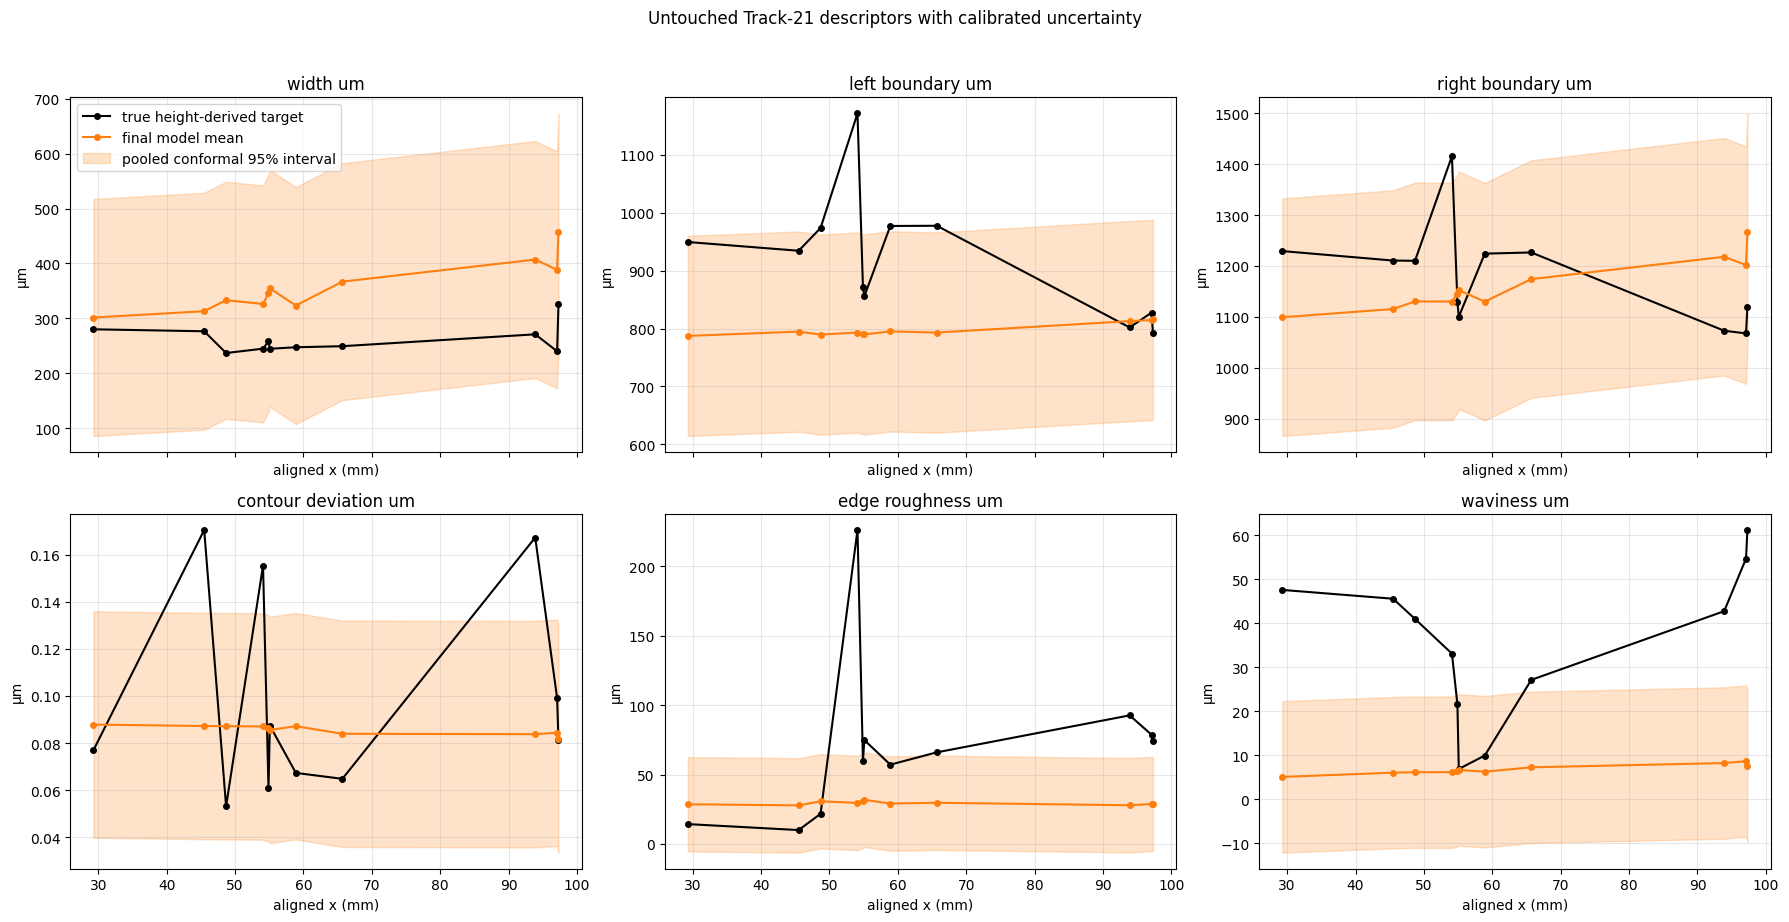

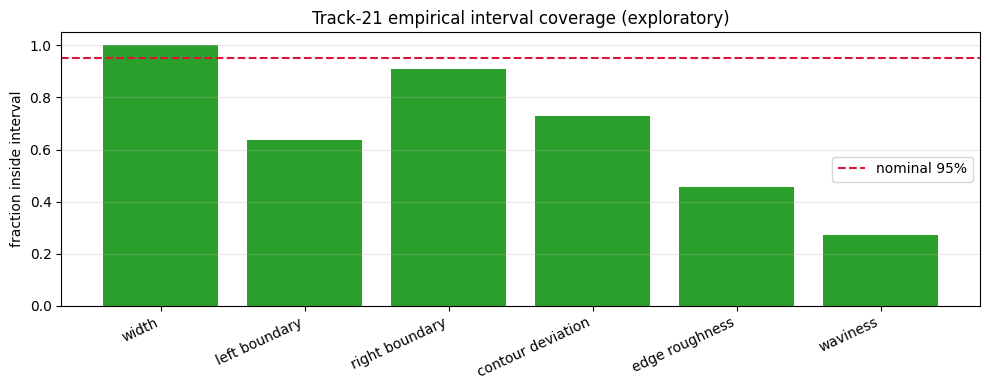

In [45]:
# 10 — Final Track-21 predictions with pooled conformal 95% uncertainty bands.
plot_data = calibrated_test_predictions.sort_values('x_mm')
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
for ax, name in zip(axes.flat, DESCRIPTOR_NAMES):
    x = plot_data['x_mm']
    ax.plot(x, plot_data[f'true_{name}'], 'o-', color='black', ms=4, label='true height-derived target')
    ax.plot(x, plot_data[f'predicted_{name}'], 'o-', color='tab:orange', ms=4, label='final model mean')
    ax.fill_between(x, plot_data[f'lower_{name}'], plot_data[f'upper_{name}'], color='tab:orange', alpha=.22, label='pooled conformal 95% interval')
    ax.set(title=name.replace('_',' '), xlabel='aligned x (mm)', ylabel='µm'); ax.grid(alpha=.3)
axes[0,0].legend(); fig.suptitle('Untouched Track-21 descriptors with calibrated uncertainty', y=1.02); fig.tight_layout(); plt.show()
plt.figure(figsize=(10,4)); plt.bar([n.replace('_um','').replace('_',' ') for n in DESCRIPTOR_NAMES], [coverage[n] for n in DESCRIPTOR_NAMES], color='tab:green')
plt.axhline(.95, color='crimson', ls='--', label='nominal 95%'); plt.ylim(0,1.05); plt.ylabel('fraction inside interval'); plt.title('Track-21 empirical interval coverage (exploratory)'); plt.xticks(rotation=25, ha='right'); plt.grid(axis='y',alpha=.3); plt.legend(); plt.tight_layout(); plt.show()